# Thesis - XAI
by Azhar Rafiq

Dataset:
- ✅[ downloaded] RSNA (kaggle.com/competitions/rsna-intracranial-hemorrhage-detection)
- [later] PhysioNet (physionet.org/content/ct-ich/1.3.1/)

In [1]:
#library
import os
from dotenv import load_dotenv

load_dotenv()

import sys
import glob

import numpy as np
import pandas as pd

import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt

import random

import tensorflow as tf
from tensorflow.keras import models, layers, losses, optimizers
from tensorflow.keras import callbacks

import joblib

#

import pydicom
from pathlib import Path
import collections

print("✅ Libraries imported succesfully\n")

print(f"🐍 Python Version: {sys.version.split()[0]}")
print(f"📖 Pandas Version: {pd.__version__}")
print(f"📖 Numpy Version: {np.__version__}")
print(f"📖 Seaborn Version: {sns.__version__}")

print(f"📖 Tensorflow Version: {tf.__version__}")
print(f"📖 Joblib Version: {joblib.__version__}")

print(f"📖 pydicom Version: {pydicom.__version__}")


I0000 00:00:1778741734.239086 2325678 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778741734.256115 2325678 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778741736.388045 2325678 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778741762.744721 2325678 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

✅ Libraries imported succesfully

🐍 Python Version: 3.12.3
📖 Pandas Version: 3.0.2
📖 Numpy Version: 2.4.4
📖 Seaborn Version: 0.13.2
📖 Tensorflow Version: 2.21.0
📖 Joblib Version: 1.5.3
📖 pydicom Version: 3.0.2


In [2]:
# #import RSNA dataset

# import kagglehub
# kagglehub.login()


In [3]:
# #specify dataset directory
# os.environ['KAGGLEHUB_CACHE'] = os.getenv('KAGGLE_CACHE')
# os.makedirs(os.environ['KAGGLEHUB_CACHE'], exist_ok=True)

# rsnapath = kagglehub.competition_download('rsna-intracranial-hemorrhage-detection')
# rsnapath
# #files already downloaded

In [4]:
#load files
#files already separated by the RSNA Kaggle Challenge

BASE = Path('.')
RSNA_TRAIN_DIR = BASE / '/rds/projects/k/karwatha-karwath-hds-pg-research/axr1222/data/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train'
RSNA_TEST_DIR = BASE / '/rds/projects/k/karwatha-karwath-hds-pg-research/axr1222/data/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_test'

#count RSNA training files
print(f'RSNA Train DICOMs: {len(list(RSNA_TRAIN_DIR.glob("*.dcm")))}')
print(f'RSNA Test DICOMs: {len(list(RSNA_TEST_DIR.glob("*.dcm")))}')

RSNA Train DICOMs: 752803
RSNA Test DICOMs: 121142


In [5]:
# no cuda/gpu used right now
#print(tf.config.list_physical_devices('GPU'))

## Exploratory Data Analysis

In [6]:
#check metadata

dcm_files = list(RSNA_TRAIN_DIR.glob('*.dcm'))
ds = pydicom.dcmread(str(dcm_files[0]))
ds

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: The value length (20) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_69e273863'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_5c33a2b716'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_9bb83869e0'. Please see <https://dicom.nema.org/medical/di

Dataset.file_meta -------------------------------
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 10000000024592
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: 'RSNA Challenge 2019'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: ID_69e273863
(0008,0060) Modality                            CS: 'CT'
(0010,0020) Patient ID                          LO: 'ID_048703f5'
(0020,000D) Study Instance UID                  UI: ID_5c33a2b716
(0020,000E) Series Instance UID                 UI: ID_9bb83869e0
(0020,0010) Study ID                            SH: ''
(0020,0032) Image Position (Patient)            DS: [-125, -13, 205.099976]
(0020,0037) Image Orientation (Patient)         DS: [1, 0, 0, 0, 1, 0]
(0028,0002) Samples per Pixel 

In [7]:
#check dicom tag keywords
# [x for x in dir(ds) if not x.startswith('_')]

This dataset possibly has 4 different kind of ID/UID:
- SOP Instance UID, patient ID, study instance UID, and series intance UID


example:

- (0008,0018) SOP Instance UID                    UI: ID_69e273863
- (0008,0060) Modality                            CS: 'CT'
- (0010,0020) Patient ID                          LO: 'ID_048703f5'
- (0020,000D) Study Instance UID                  UI: ID_5c33a2b716
- (0020,000E) Series Instance UID                 UI: ID_9bb83869e0

I will analyse all the DICOM metadata.

In [8]:
#log all metadata in csv
#move to slurm

Checking raw image data:

In [9]:
ds.pixel_array

array([[11, 11, 12, ..., 12, 11, 10],
       [12, 12, 12, ..., 12, 11, 11],
       [12, 13, 13, ..., 12, 12, 13],
       ...,
       [15, 15, 14, ..., 15, 15, 15],
       [15, 15, 14, ..., 14, 14, 15],
       [14, 15, 15, ..., 14, 14, 15]], shape=(512, 512), dtype=uint16)

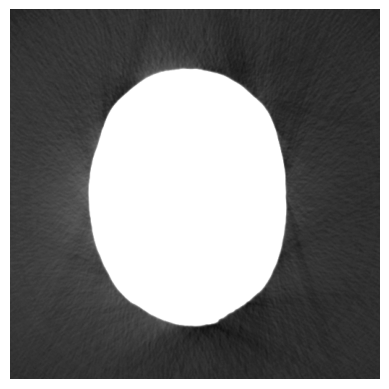

In [10]:
#show image using raw pixel_array
ds = pydicom.dcmread(str(dcm_files[0]))
pixel_array = ds.pixel_array.astype(np.float32)
plt.imshow(pixel_array, cmap='gray', vmin=0, vmax=80)
plt.axis('off')
plt.show()

The original DICOM will shows image too bright, 
so I need to convert to Hounsfield Units (HU) 
using rescale intercept and slope.


example from image index[0]:
(0028,1052) Rescale Intercept                   DS: '-1024'
(0028,1053) Rescale Slope                       DS: '1'

In [11]:
ds.RescaleIntercept

'-1024'

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_5c33a2b716'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_d7a634ec77'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


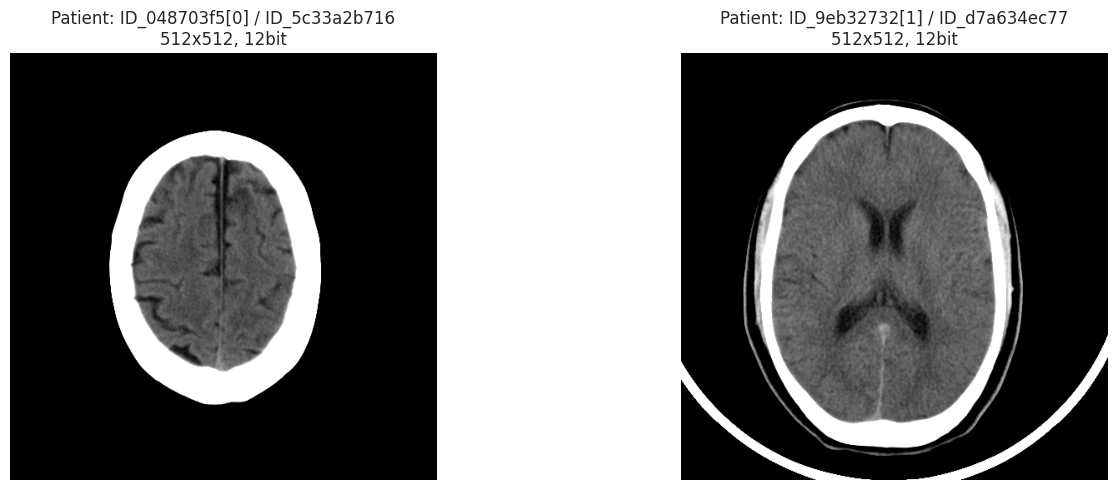

In [27]:
#show image with hounsfield unit
if dcm_files:
    n_images = 2
    n_cols = 2
    n_rows = (n_images + n_cols - 1) // n_cols  #ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i in range(n_images):
        ds = pydicom.dcmread(str(dcm_files[i]))
        pixel_array = ds.pixel_array.astype(np.float32)
        
        #converts to Hounsfield Units
        hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

        axes[i].imshow(hu, cmap='gray', vmin=0, vmax=80)
        axes[i].set_title(f'Patient: {ds.PatientID}[{i}] / {ds.StudyInstanceUID}\n{ds.Rows}x{ds.Columns}, {ds.BitsStored}bit')
        axes[i].axis('off')

    #hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

It is logical to have different study patient ID each patient, but if:
1. MULTIPLE IMAGE of SAME patient ID + SAME study ID = one patient have multiple slices in same study
2. MULTIPLE IMAGE of SAME patient ID + DIFFERENT study ID = one patient have multiple study (repeat/different CT Scan)

Analysing metadata:

Check non unique IDs count to show how many images are not only 1 slice from 1 patient:

In [ ]:
df = pd.read_csv('rsna_dicom_index.csv') #output of slurm job

print('PatientID ---')
print(df.groupby('split')['PatientID'].nunique())
print('StudyInstanceUID ---')
print(df.groupby('split')['StudyInstanceUID'].nunique())
print('SeriesInstanceUID ---')
print(df.groupby('split')['SeriesInstanceUID'].nunique())
print('SOPInstanceUID ---')
print(df.groupby('split')['SOPInstanceUID'].nunique())

PatientID ---
split
test      3518
train    18938
Name: PatientID, dtype: int64 ooo
StudyInstanceUID ---
split
test      3518
train    21744
Name: StudyInstanceUID, dtype: int64
SeriesInstanceUID ---
split
test      3518
train    21744
Name: SeriesInstanceUID, dtype: int64
SOPInstanceUID ---
split
test     121142
train    752803
Name: SOPInstanceUID, dtype: int64


In [22]:
#summarizing
summary = df.groupby('split').agg(
    Total_Files       = ('filename',         'count'),
    Unique_Patients   = ('PatientID',        'nunique'),
    Unique_Studies    = ('StudyInstanceUID',  'nunique'),
    Unique_Series     = ('SeriesInstanceUID', 'nunique'),
    Unique_Slices     = ('SOPInstanceUID',    'nunique'),
).T

summary['total'] = summary.sum(axis=1)

# Slices per group
summary.loc['Avg Slices per Patient'] = (summary.loc['Total_Files'] / summary.loc['Unique_Patients']).round(1)
summary.loc['Avg Slices per Study']   = (summary.loc['Total_Files'] / summary.loc['Unique_Studies']).round(1)
summary.loc['Avg Slices per Series']  = (summary.loc['Total_Files'] / summary.loc['Unique_Series']).round(1)

print(summary.to_string())

split                       test     train     total
Total_Files             121142.0  752803.0  873945.0
Unique_Patients           3518.0   18938.0   22456.0
Unique_Studies            3518.0   21744.0   25262.0
Unique_Series             3518.0   21744.0   25262.0
Unique_Slices           121142.0  752803.0  873945.0
Avg Slices per Patient      34.4      39.8      38.9
Avg Slices per Study        34.4      34.6      34.6
Avg Slices per Series       34.4      34.6      34.6


This is apparently volumetric dataset. Each patient has its own multiple CT Scan slices. I should check the sample for a patient:

In [28]:
check_sample = df[df['PatientID']=="ID_048703f5"]
check_sample.count()

filename             40
split                40
PatientID            40
StudyInstanceUID     40
SeriesInstanceUID    40
SOPInstanceUID       40
dtype: int64

In [29]:
check_sample

,filename,split,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID
0,ID_69e273863.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_69e273863
8638,ID_6a56f4d7d.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_6a56f4d7d
20797,ID_abe7db767.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_abe7db767
29122,ID_0082f9066.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_0082f9066
70326,ID_9960426fa.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_9960426fa
103197,ID_ee3626bdd.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_ee3626bdd
121123,ID_a003e82fd.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_a003e82fd
121583,ID_b8aa09f9f.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_b8aa09f9f
130747,ID_30ca14fbe.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_30ca14fbe
180769,ID_f79a78e9c.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_f79a78e9c


In [39]:
#rerun slurm to fetch other metadata to check image order of the study

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_5c33a2b716'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


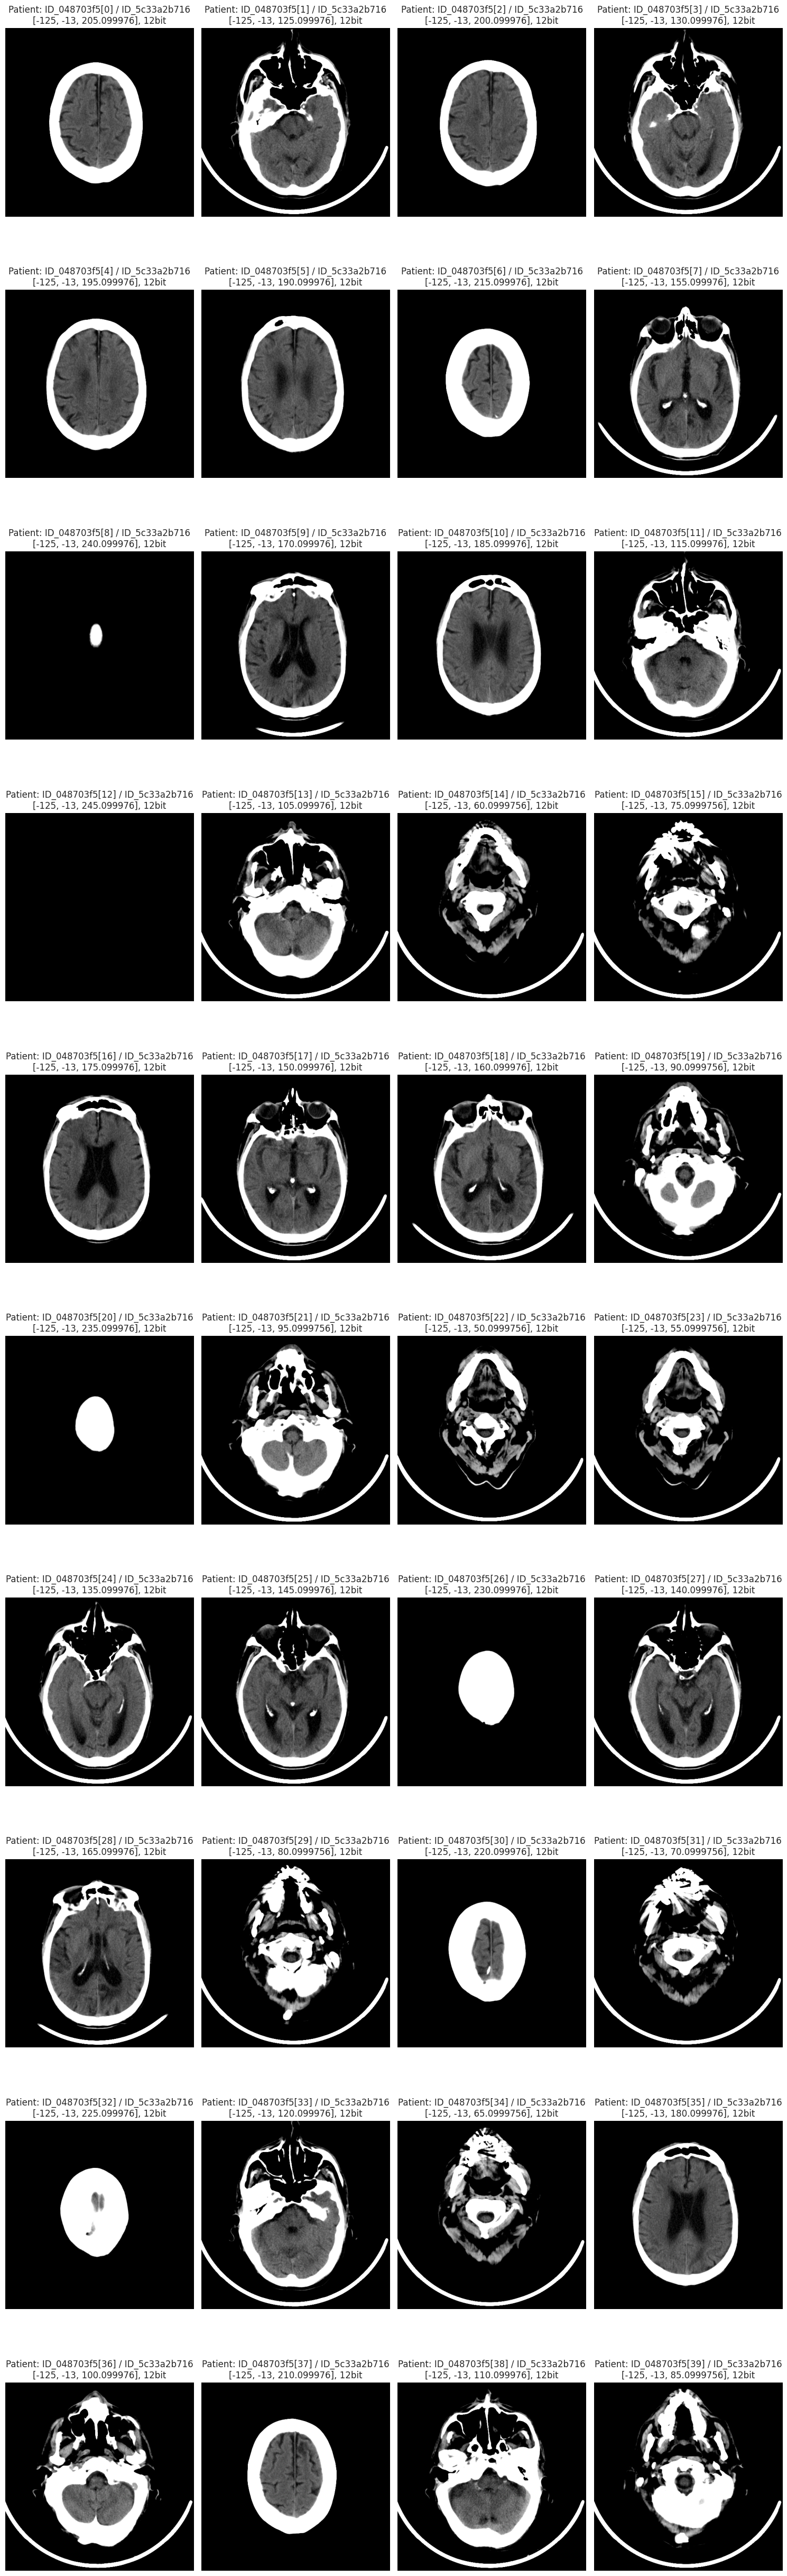

In [ ]:
#show images for this patient
if dcm_files:
    n_images = 40
    n_cols = 4
    n_rows = (n_images + n_cols - 1) // n_cols  #ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i in range(n_images):
        file_path = RSNA_TRAIN_DIR / check_sample.iloc[i]['filename']
        ds = pydicom.dcmread(str(file_path))
        pixel_array = ds.pixel_array.astype(np.float32)
        
        #converts to Hounsfield Units
        hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

        axes[i].imshow(hu, cmap='gray', vmin=0, vmax=80)
        #apparently they have ds.ImagePositionPatient metadata
        axes[i].set_title(f'Patient: {ds.PatientID}[{i}] / {ds.StudyInstanceUID}\n{ds.ImagePositionPatient}, {ds.BitsStored}bit')
        axes[i].axis('off')

    #hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

So it is truly volumetric. But doesn't seems organised. The `ImagePositionPatient` has 3 values [x,y,z] and z is the order.

Check if there are overlap patients (using `PatientID`) between train/test data to prevent data leak:

In [31]:
train_patients = set(df[df.split=='train']['PatientID'])
test_patients  = set(df[df.split=='test']['PatientID'])
print(f"Patient overlap between train and test: {len(train_patients & test_patients)}")

Patient overlap between train and test: 0


There is no data with same patientID across train/test dataset given by RSNA.

Check empty values

## Preprocessing

Set the random seed to allow reproducibiliy of the research before preprocessing:

In [32]:
#seed
SEED = 20260605
def change_seed(SEED=42):
    #lock python and libraries random generator to make sure reproducibility
    os.environ['PYTHONHASHSEED'] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
change_seed(SEED) #using the assigned seed